**Titanic** **Survival** **Prediction**

Importing Dependencies

In [250]:
# Import NumPy for numerical calculations and array operations
import numpy as np

# Import Pandas for data loading and manipulation
import pandas as pd

# Import Matplotlib for creating charts and graphs
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import Logistic Regression algorithm for classification
from sklearn.linear_model import LogisticRegression

# Import accuracy_score to evaluate the model's prediction accuracy
from sklearn.metrics import accuracy_score

Data Collection and Processing

In [251]:
# load the data from csv file to Pandas DataFrame
titanic_data = pd.read_csv('Titanic Dataset.csv')

# printing the first 5 rows of the dataframe
titanic_data.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [252]:
# Number of rows and columns
titanic_data.shape

(891, 12)

In [253]:
# Getting some informantion about data
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [254]:
# Check the number of missing values in each column
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Handling Missing Values

In [255]:
# Drop the "Cabin" column from dataframe
titanic_data = titanic_data.drop(columns='Cabin', axis=1)

In [256]:
# Replacing missing values in "Age" column with mean value
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].mean())
print(titanic_data['Age'])

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64


In [257]:
# Finding the mode value of "Embarked" column
print(titanic_data['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [258]:
print(titanic_data['Embarked'].mode()[0])

S


In [259]:
# Replacing missing values in "Embarked" column with mode value
titanic_data['Embarked']= titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0])
print(titanic_data['Embarked'])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object


In [260]:
# Check the number of missing values in each column
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Data Analysis

In [261]:
# Getting statictical measures about data
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [262]:
# Finding number of people survived and not survived
titanic_data['Survived'].value_counts()

,count
Survived,
0,549
1,342


Data Visualization

In [263]:
sns.set()

[Text(0, 0, '549'), Text(0, 0, '342')]

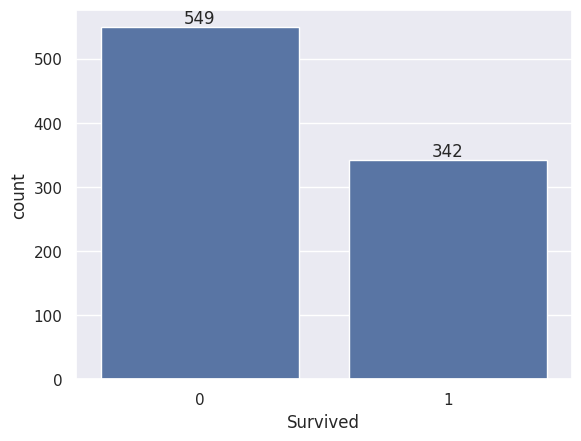

In [264]:
#Survival Distribution

# Making count plot for "Survived" column
ax = sns.countplot(x='Survived', data=titanic_data)

# Adding data labels
ax.bar_label(ax.containers[0])

In [265]:
# Finding number of male and female survived and not survived
titanic_data['Sex'].value_counts()

,count
Sex,
male,577
female,314


[Text(0, 0, '577'), Text(0, 0, '314')]

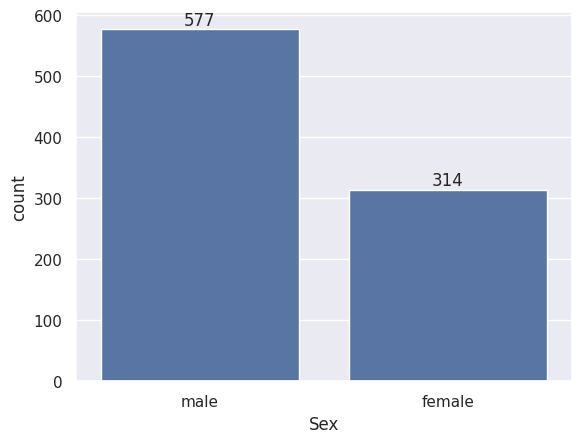

In [266]:
#Gender Distribution

# Making count plot for "Sex" column
ax = sns.countplot(x='Sex', data=titanic_data)

# Adding data labels
ax.bar_label(ax.containers[0])

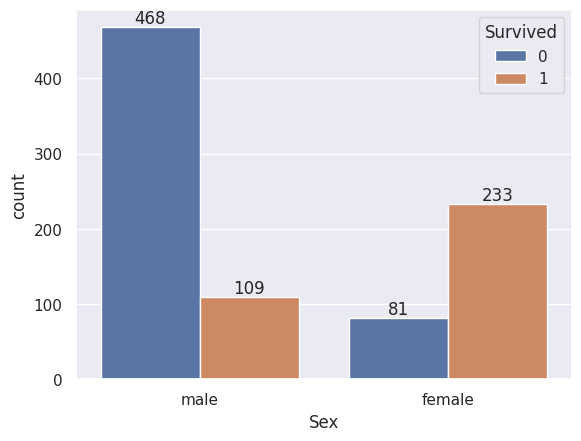

In [267]:
#Survival by Gender

# Number of survivors "Gender" wise
ax = sns.countplot(x='Sex', hue='Survived', data=titanic_data)

# Adding data labels
for container in ax.containers:
    ax.bar_label(container)

[Text(0, 0, '216'), Text(0, 0, '184'), Text(0, 0, '491')]

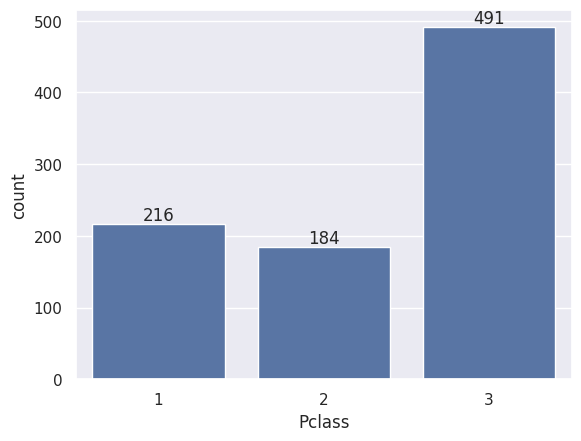

In [268]:
#Passenger Class Distribution

# Making count plot for "Pclass" column
ax = sns.countplot(x='Pclass', data=titanic_data)

# Adding data labels
ax.bar_label(ax.containers[0])

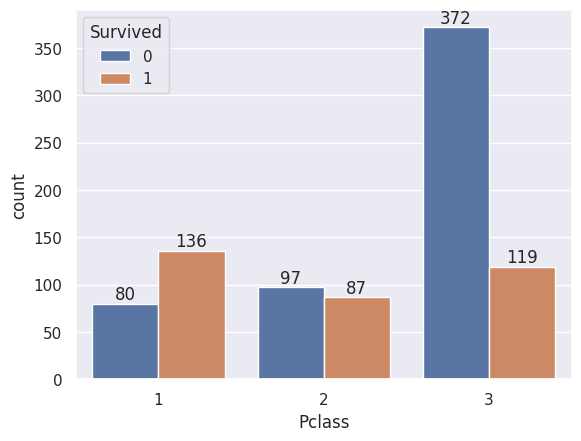

In [269]:
# Survival by Passenger Class

# Making count plot for "Pclass" column for survivors and non-survivors
ax = sns.countplot(x='Pclass', hue='Survived', data=titanic_data)

# Adding data labels
for container in ax.containers:
    ax.bar_label(container)

[Text(0, 0, '646'), Text(0, 0, '168'), Text(0, 0, '77')]

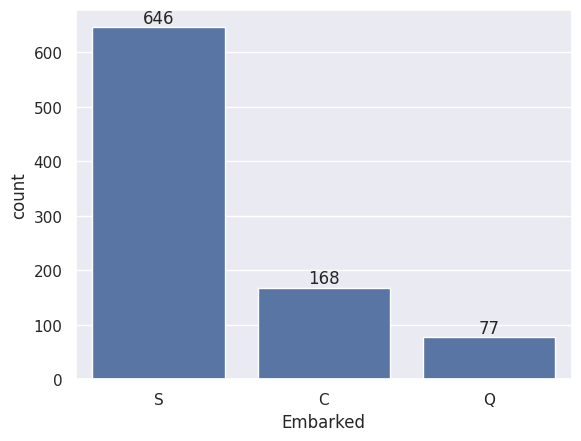

In [270]:
#Embarked Distribution

# Making count plot for "Embarked" column
ax = sns.countplot(x='Embarked', data=titanic_data)

# Adding data labels
ax.bar_label(ax.containers[0])

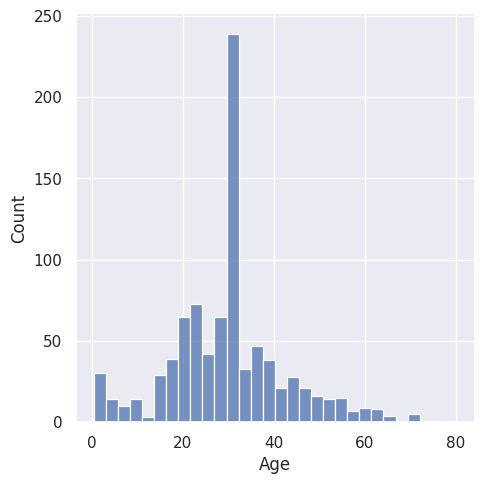

In [271]:
#Age Distribution

# Making distribution plot for "Age" column
sns.displot(titanic_data['Age'])

# Adding data labels is not normally applicable to a distribution plot

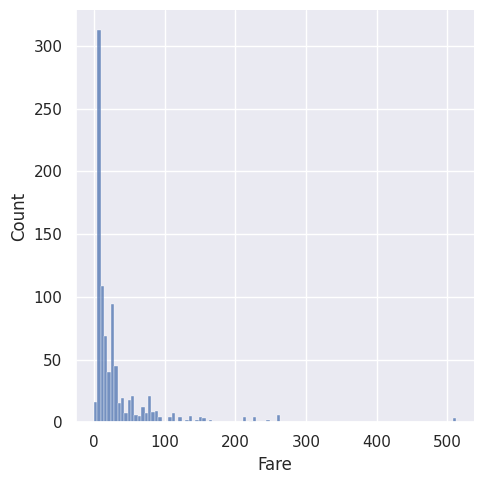

In [272]:
# Making distribution plot for "Fare" column
sns.displot(titanic_data['Fare'])

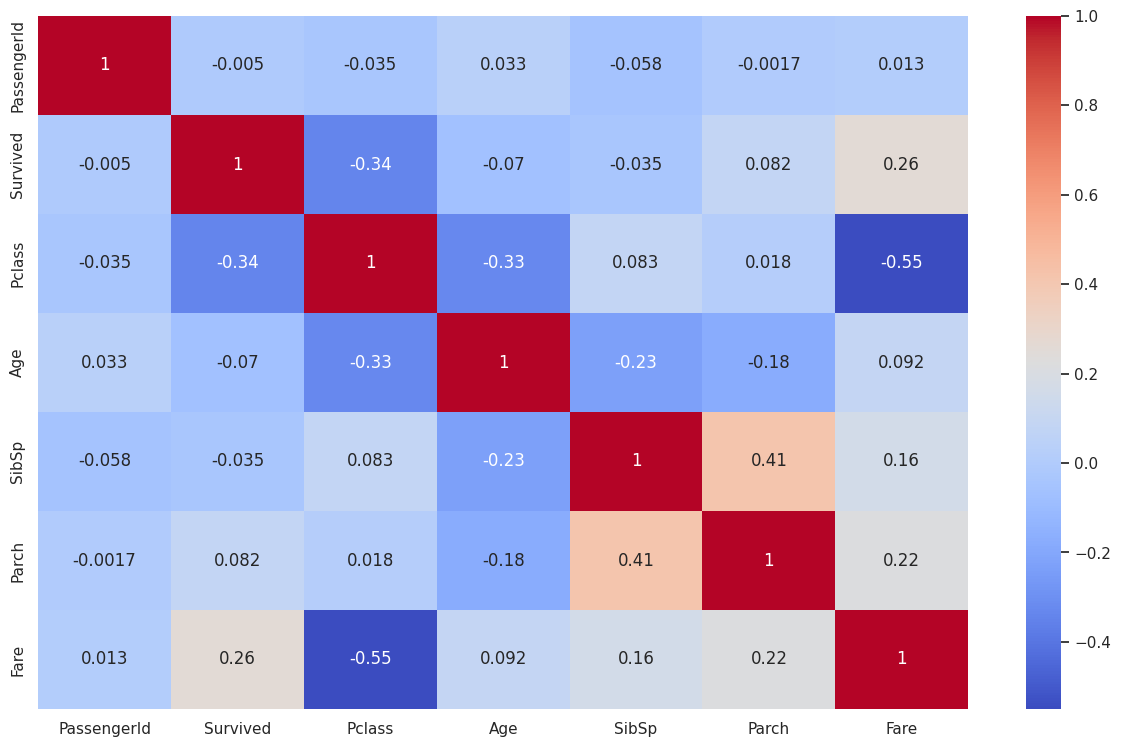

In [273]:
# Selecting only numeric columns
numeric_columns = titanic_data.select_dtypes(include=['float64', 'int64'])

# Calculating correlations between numeric columns
corr = numeric_columns.corr()

# Making heatmap for correlation between numeric columns
plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Displaying the heatmap
plt.show()

Encoding Categorical Columns

In [274]:
# Finding the number of male and female passengers
titanic_data['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [275]:
# Finding the number of passengers from each embarkation port
titanic_data['Embarked'].value_counts()


,count
Embarked,
S,646
C,168
Q,77


In [276]:
# Converting categorical values into numerical values
titanic_data['Sex'] = titanic_data['Sex'].map({'male': 0, 'female': 1})
titanic_data['Embarked'] = titanic_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


In [277]:
# Displaying the first five rows of the dataset
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


Seperating Features & Target

In [278]:
# Separating the features and target variable
# X = Information used to make the prediction
# Y = What we want to predict

X = titanic_data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Survived'], axis=1)
Y = titanic_data['Survived']

In [279]:
print(X)

     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3    0  22.000000      1      0   7.2500         0
1         1    1  38.000000      1      0  71.2833         1
2         3    1  26.000000      0      0   7.9250         0
3         1    1  35.000000      1      0  53.1000         0
4         3    0  35.000000      0      0   8.0500         0
..      ...  ...        ...    ...    ...      ...       ...
886       2    0  27.000000      0      0  13.0000         0
887       1    1  19.000000      0      0  30.0000         0
888       3    1  29.699118      1      2  23.4500         0
889       1    0  26.000000      0      0  30.0000         1
890       3    0  32.000000      0      0   7.7500         2

[891 rows x 7 columns]


In [280]:
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


Splitting data into Training data & Test data

In [281]:
# Splitting the dataset into training (80%) and testing (20%) sets for model training and evaluation
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [282]:
# Displaying the shape of the original dataset, training dataset, and testing dataset
print(X.shape, X_train.shape, X_test.shape)

(891, 7) (712, 7) (179, 7)


Model Training

Logistic Regression

In [283]:
# Creating the Logistic Regression model
model = LogisticRegression(max_iter=1000)

In [284]:
# Training Logistic Regrssion model with Training data
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

Model Evaluation


Accuracy Score

In [285]:
# Predicting the survival outcome for the training data using the trained Logistic Regression model
X_train_prediction = model.predict(X_train)

In [286]:
print(X_train_prediction)

[0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 1 0 1
 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 0
 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0
 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0
 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 0
 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 1 1
 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0
 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0
 0 1 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0
 0 0 0 0 1 0 0 1 0 1 1 0 

In [287]:
# Calculating and displaying the accuracy of the model on the training dataset
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('Accuracy score of training data : ', training_data_accuracy)

Accuracy score of training data :  0.8089887640449438


In [288]:
# Predicting the survival status of the passengers in the testing dataset
X_test_prediction = model.predict(X_test)

In [289]:
print(X_test_prediction)

[0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0
 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 0 0 0 0
 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0 0
 0 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 0 0]


In [290]:
# Calculating and displaying the accuracy of the model on the testing dataset
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Accuracy score of test data : ', test_data_accuracy)

Accuracy score of test data :  0.7821229050279329
